In [1]:
import pandas as pd
import os
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler

In [10]:
#data = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/df_one_hot_encoded_171025.csv', sep = ',')

In [11]:
#columns_to_drop = ['№', 'id', 'title', 'description', 'key_skills', 'location', 'date_of_post', 'type', 'salary_to', 'currency', 'description_clean', 'salary_from_company_coefficient','salary_to_company_coefficient', 'salary_from_title_coefficient', 'salary_to_title_coefficient', 'salary_from_filled',]
#data_clean = data.drop(columns=columns_to_drop)

In [12]:
#def show_missing_percentage(df):
    #"""
    #Выводит процент пропущенных значений для каждого столбца
    #"""
    #total_rows = len(df)
    #missing_percent = (df.isnull().sum() / total_rows) * 100
    
    #print("Процент пропущенных значений по столбцам:")
    #print("-" * 50)
    #for col, percent in missing_percent.items():
        #print(f"{col}: {percent:.2f}%")
    
    #return missing_percent

# Использование
#missing_percent = show_missing_percentage(data_clean)

In [13]:
def fill_with_mode_simple(df, column_name):
    #"""
    #Заполняет пропуски в столбце самым частотным значением
    #"""
    #df_copy = df.copy()
    
    # Находим самое частотное значение (игнорируя NaN)
    #mode_value = df_copy[column_name].mode()
    
    #if not mode_value.empty:
        #most_frequent = mode_value.iloc[0]
        #print(f"Самое частотное значение в '{column_name}': {most_frequent}")
        
        # Заполняем пропуски
        #df_copy[column_name] = df_copy[column_name].fillna(most_frequent)
    #else:
        #print(f"Не удалось найти самое частотное значение в '{column_name}'")
    
    #return df_copy

In [14]:
#data_clean_filled = fill_with_mode_simple(data_clean, 'experience_from')

In [15]:
#data_clean_filled = fill_with_mode_simple(data_clean_filled, 'experience_to')

In [16]:
#data_clean_filled.to_csv('data_clean_one_hot_encoddecd_filled.csv')

In [2]:
data_clean_filled = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/data_clean_one_hot_encoddecd_filled.csv', sep = ',')

In [3]:
data_clean_filled

,Unnamed: 0.1,Unnamed: 0,salary_from,experience_from,experience_to,no_experience,city_воронеж,city_деревня,city_екатеринбур,city_ижевск,...,title_key_электромонтер,title_key_электросварщик,title_key_энергетик,title_key_юрисконсульт,title_key_юрист,month_4,month_5,month_6,month_8,month_9
0,0,0,160000.0,6.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,5,62000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2,6,130000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,7,80000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,4,8,250000.0,6.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332049,332049,562927,200000.0,3.0,6.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332050,332050,562945,350000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332051,332051,562952,200000.0,3.0,6.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332052,332052,562972,90000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Линейная регрессия

In [4]:
X = data_clean_filled.loc[data_clean_filled["salary_from"].notnull(), :].drop(
    "salary_from", axis=1
)
y = data_clean_filled["salary_from"][X.index]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

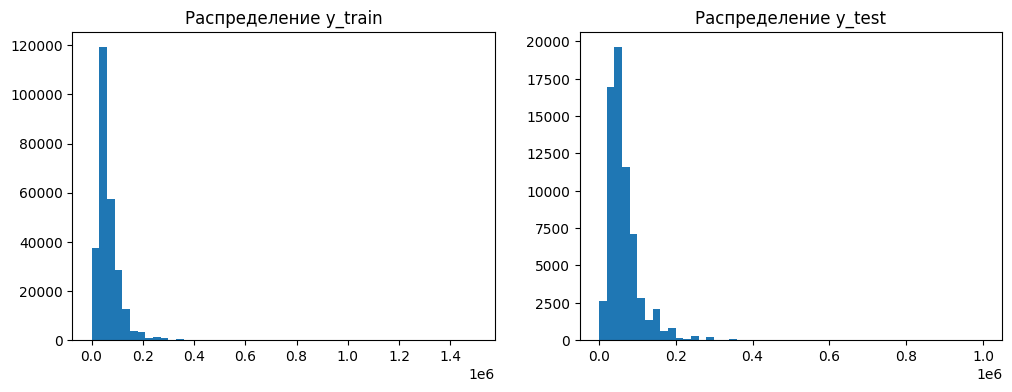

y_train stats: min=1.00, max=1500000.00, std=46836.77
y_test stats: min=2.00, max=1000000.00, std=47093.28


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Проверка выбросов в целевой переменной
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50)
plt.title('Распределение y_train')

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=50) 
plt.title('Распределение y_test')

plt.show()

# Количественная проверка
print(f"y_train stats: min={y_train.min():.2f}, max={y_train.max():.2f}, std={y_train.std():.2f}")
print(f"y_test stats: min={y_test.min():.2f}, max={y_test.max():.2f}, std={y_test.std():.2f}")

In [7]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train)
X_test_normalized = normalizer.transform(X_test)   

X_train_normalized = pd.DataFrame(X_train_normalized, columns=normalizer.get_feature_names_out())
X_test_normalized = pd.DataFrame(X_test_normalized, columns=normalizer.get_feature_names_out())

In [9]:
def check_data_issues(X_train, X_test, y_train, y_test):
    print("=== ДИАГНОСТИКА ДАННЫХ ===")
    
    # 1. Размеры
    print(f"Размеры: X_train {X_train_normalized.shape}, X_test {X_test.shape}")
    
    # 2. Пропуски
    print(f"Пропуски в train: {X_train.isnull().sum().sum()}")
    print(f"Пропуски в test: {X_test.isnull().sum().sum()}")
    
    # 3. Статистики
    print("\nСтатистики по первому признаку:")
    print(f"Train - mean: {X_train.iloc[:, 0].mean():.2f}, std: {X_train.iloc[:, 0].std():.2f}")
    print(f"Test  - mean: {X_test.iloc[:, 0].mean():.2f}, std: {X_test.iloc[:, 0].std():.2f}")
    
    # 4. Масштабы признаков
    print("\nМасштабы признаков (min/max):")
    for i in range(min(3, X_train.shape[1])):
        train_range = X_train.iloc[:, i].max() - X_train.iloc[:, i].min()
        test_range = X_test.iloc[:, i].max() - X_test.iloc[:, i].min()
        print(f"Признак {i}: train {train_range:.2f}, test {test_range:.2f}")

check_data_issues(X_train_normalized, X_test_normalized, y_train, y_test)

=== ДИАГНОСТИКА ДАННЫХ ===
Размеры: X_train (265643, 236), X_test (66411, 236)
Пропуски в train: 0
Пропуски в test: 0

Статистики по первому признаку:
Train - mean: 0.50, std: 0.29
Test  - mean: 0.50, std: 0.29

Масштабы признаков (min/max):
Признак 0: train 1.00, test 1.00
Признак 1: train 1.00, test 1.00
Признак 2: train 1.00, test 1.00


In [10]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Создаем модели
lr = LinearRegression()
ridge = Ridge(alpha=1.0)    # параметр регуляризации
lasso = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models = {
    'Linear Regression': lr,
    'Ridge': ridge, 
    'Lasso': lasso 
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_normalized, y_train_log)
    
    # Предсказания
    pred_train = np.expm1(model.predict(X_train_normalized))
    pred_test = np.expm1(model.predict(X_test_normalized))
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 37652.97
Test RMSE: 38178.77
Train R²: 0.3537
Test R²: 0.3427

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 37848.52
Test RMSE: 38260.12
Train R²: 0.3470
Test R²: 0.3399

=== Lasso ===
Train RMSE: 48158.62
Test RMSE: 48421.52
Train R²: -0.0572
Test R²: -0.0572


In [26]:
errors = y_test - pred_test

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


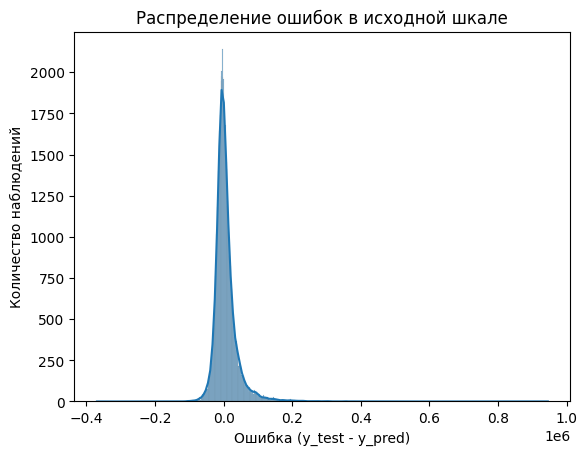

In [27]:
sns.histplot(errors, kde=True)
plt.title("Распределение ошибок в исходной шкале")
plt.xlabel("Ошибка (y_test - y_pred)")
plt.ylabel("Количество наблюдений")
plt.show()

In [28]:
idx = np.argsort(np.abs(errors))[-50:]
print(y_test.iloc[idx])
print(pred_test[idx])

198070     460000.0
51006      480000.0
13382      500000.0
207967     500000.0
324549     449000.0
330501     500000.0
324068     500000.0
199243     500000.0
235860     500000.0
99660      500000.0
301122     500000.0
318847     500000.0
21751      500000.0
108932     500000.0
307806     500000.0
312175     480000.0
193160     500000.0
193958     500000.0
56554      550000.0
105424     500000.0
73062      500000.0
225800     500000.0
11642      500000.0
288258     550000.0
130784     600000.0
319959     650000.0
81781      600000.0
266236     600000.0
177926     600000.0
285550     600000.0
207390     650000.0
304947     700000.0
8361       700000.0
15774      750000.0
174493     700000.0
271533     700000.0
279614     700000.0
295831     700000.0
302936     700000.0
307450     700000.0
216508     800000.0
102565     800000.0
313956     900000.0
70233     1000000.0
231138    1000000.0
148056    1000000.0
125572    1000000.0
88516     1000000.0
110797    1000000.0
46359     1000000.0


## Попробуем убрать выборосы по правилу межквартильного размаха

In [59]:
def remove_outliers_iqr(data, column):
    """
    Удаляет выбросы по методу IQR
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 4.0 * IQR
    upper_bound = Q3 + 4.0 * IQR
    
    # Фильтруем данные
    data_filtered = data[(data[column] >= lower_bound) & 
                         (data[column] <= upper_bound)]
    
    # ИСПРАВЛЕНИЕ: преобразуем в float для форматирования
    print(f"Границы для {column}: [{float(lower_bound):.2f}, {float(upper_bound):.2f}]")
    print(f"Удалено {len(data) - len(data_filtered)} выбросов")
    
    return data_filtered

In [60]:
df_clean_iqr = remove_outliers_iqr(data_clean_filled, 'salary_from')

Границы для salary_from: [-120000.00, 240000.00]
Удалено 3509 выбросов


In [61]:
X_without_outliers = df_clean_iqr.loc[df_clean_iqr["salary_from"].notnull(), :].drop(
    "salary_from", axis=1
)
y_without_outliers = df_clean_iqr["salary_from"][X_without_outliers.index]

In [62]:
from sklearn.model_selection import train_test_split

X_train_without_outliers, X_test_without_outliers, y_train_without_outliers, y_test_without_outliers = train_test_split(X_without_outliers, y_without_outliers, test_size=0.2, random_state=1)

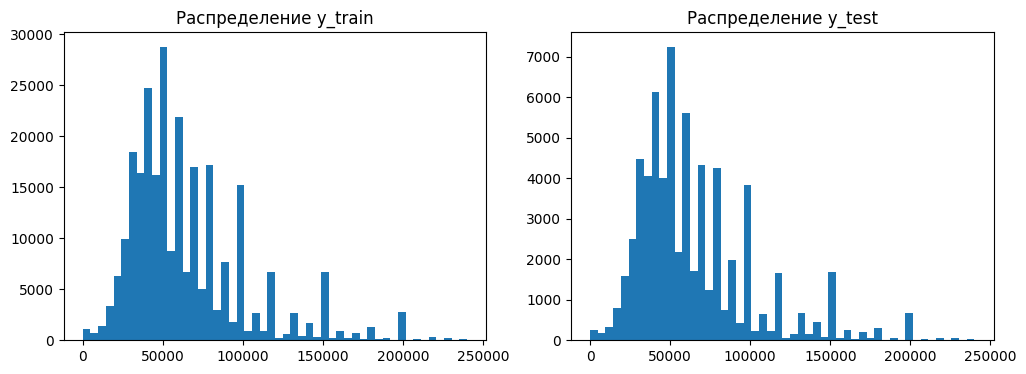

y_train stats: min=1.00, max=240000.00, std=37264.66
y_test stats: min=1.00, max=240000.00, std=37167.40


In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Проверка выбросов в целевой переменной
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train_without_outliers, bins=50)
plt.title('Распределение y_train')

plt.subplot(1, 2, 2)
plt.hist(y_test_without_outliers, bins=50) 
plt.title('Распределение y_test')

plt.show()

# Количественная проверка
print(f"y_train stats: min={y_train_without_outliers.min():.2f}, max={y_train_without_outliers.max():.2f}, std={y_train_without_outliers.std():.2f}")
print(f"y_test stats: min={y_test_without_outliers.min():.2f}, max={y_test_without_outliers.max():.2f}, std={y_test_without_outliers.std():.2f}")

In [64]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
X_without_outliers_train_normalized = normalizer.fit_transform(X_train_without_outliers)
X_without_outliers_test_normalized = normalizer.transform(X_test_without_outliers)   

X_without_outliers_train_normalized = pd.DataFrame(X_without_outliers_train_normalized, columns=normalizer.get_feature_names_out())
X_without_outliers_test_normalized = pd.DataFrame(X_without_outliers_test_normalized, columns=normalizer.get_feature_names_out())

In [65]:
y_train_without_outliers_log = np.log1p(y_train_without_outliers)
y_test_without_outliers_log = np.log1p(y_test_without_outliers)

In [13]:
# Создаем модели
lr_without_outliers = LinearRegression()
ridge_without_outliers = Ridge(alpha=1.0)    # параметр регуляризации
lasso_without_outliers = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models_without_outliers = {
    'Linear Regression': lr_without_outliers,
    'Ridge': ridge_without_outliers, 
    'Lasso': lasso_without_outliers 
}

for name_n, model_m in models_without_outliers.items():
    print(f"\n=== {name_n} ===")
    
    # Обучение
    model_m.fit(X_without_outliers_train_normalized, y_train_without_outliers_log)
    
    # Предсказания
    pred_train = np.expm1(model_m.predict(X_without_outliers_train_normalized))
    pred_test = np.expm1(model_m.predict(X_without_outliers_test_normalized))
 

    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train_without_outliers, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test_without_outliers, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train_without_outliers, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test_without_outliers, pred_test):.4f}")


=== Linear Regression ===


NameError: name 'X_without_outliers_train_normalized' is not defined

## Добавим PCA

In [55]:
# PCA для уменьшения мультиколлинеарности
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)  # 95% дисперсии
X_train_pca = pca.fit_transform(X_train_normalized)
X_test_pca = pca.transform(X_test_normalized)

print(f"Исходные признаки: {X_train_normalized.shape[1]}")
print(f"После PCA: {X_train_pca.shape[1]}")

Исходные признаки: 236
После PCA: 181


In [56]:
# Создаем модели
lr_PCA= LinearRegression()
ridge_PCA = Ridge(alpha=1.0)    # параметр регуляризации
lasso_PCA = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models = {
    'Linear Regression': lr_PCA,
    'Ridge': ridge_PCA, 
    'Lasso': lasso_PCA
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_pca, y_train_log)
    
    # Предсказания
    pred_train = np.expm1(model.predict(X_train_pca))
    pred_test = np.expm1(model.predict(X_test_pca))
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train_log, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test_log, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 66619.77
Test RMSE: 66699.76
Train R²: 0.3272
Test R²: 0.3297

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 66614.25
Test RMSE: 66694.19
Train R²: 0.3271
Test R²: 0.3297

=== Lasso ===
Train RMSE: 56509.71
Test RMSE: 56509.71
Train R²: -0.0572
Test R²: -0.0572


## Случайный лес с грид-серчем

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Создание и обучение модели без подбора параметров
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Начинаем обучение Random Forest...")
rf_model.fit(X_train_normalized, y_train_log)

# Предсказания
y_pred_train_log = rf_model.predict(X_train_normalized)
y_pred_test_log = rf_model.predict(X_test_normalized)

# Преобразование обратно из логарифмической шкалы
y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)

# Оценка качества
print("\n" + "="*50)
print("ОЦЕНКА RandomForestRegressor")
print("="*50)

# Метрики для train
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"\n=== TRAIN ===")
print(f"RMSE: {train_rmse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"R²: {train_r2:.4f}")

# Метрики для test
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\n=== TEST ===")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAE: {test_mae:.2f}")
print(f"R²: {test_r2:.4f}")

# Разница между train и test (проверка на переобучение)
print(f"\n=== ПЕРЕОБУЧЕНИЕ ===")
print(f"RMSE разница: {test_rmse - train_rmse:.2f}")
print(f"R² разница: {train_r2 - test_r2:.4f}")

Начинаем обучение Random Forest...

ОЦЕНКА RandomForestRegressor

=== TRAIN ===
RMSE: 17925.16
MAE: 8826.79
R²: 0.8535

=== TEST ===
RMSE: 38901.79
MAE: 22675.77
R²: 0.3176

=== ПЕРЕОБУЧЕНИЕ ===
RMSE разница: 20976.63
R² разница: 0.5359


In [12]:
from sklearn.ensemble import RandomForestRegressor

# Более строгие параметры против переобучения
rf_model_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,           # Ограничиваем глубину
    min_samples_split=5,   # Минимум 10 samples для разделения
    min_samples_leaf=5,     # Минимум 5 samples в листе
    max_features=0.5,       # Используем только 30% признаков
    random_state=42,
    n_jobs=-1
)

rf_model_tuned.fit(X_train_normalized, y_train_log)

# Предсказания и оценка
train_pred_tuned = np.expm1(rf_model_tuned.predict(X_train_normalized))
test_pred_tuned = np.expm1(rf_model_tuned.predict(X_test_normalized))

print("=== Random Forest с регуляризацией ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred_tuned)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred_tuned)):.2f}")
print(f"Train R²: {r2_score(y_train, train_pred_tuned):.4f}")
print(f"Test R²: {r2_score(y_test, test_pred_tuned):.4f}")

=== Random Forest с регуляризацией ===
Train RMSE: 37214.84
Test RMSE: 38344.02
Train R²: 0.3687
Test R²: 0.3370


In [76]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=18,
    learning_rate=0.1,
    subsample=0.8,  # Используем 80% данных для каждого дерева
    random_state=42
)

gb_model.fit(X_train_normalized, y_train_log)

train_pred_gb = np.expm1(gb_model.predict(X_train_normalized))
test_pred_gb = np.expm1(gb_model.predict(X_test_normalized))

print("=== Gradient Boosting ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred_gb)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred_gb)):.2f}")
print(f"Разница: {np.sqrt(mean_squared_error(y_test, test_pred_gb)) - np.sqrt(mean_squared_error(y_train, train_pred_gb)):.2f}")

=== Gradient Boosting ===
Train RMSE: 29883.36
Test RMSE: 36945.00
Разница: 7061.65


## BOW

In [ ]:
data = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/df_one_hot_encoded_171025.csv', sep = ',')

In [ ]:
columns_to_drop = ['Unnamed: 0', '№', 'id', 'title',  'key_skills', 'location', 'date_of_post', 'type', 'salary_to', 'currency', 'description_clean', 'salary_from_company_coefficient','salary_to_company_coefficient', 'salary_from_title_coefficient', 'salary_to_title_coefficient', 'salary_from_filled',]
data.drop(columns=columns_to_drop, inplace=True)

In [ ]:
data

,description,salary_from,experience_from,experience_to,no_experience,city_воронеж,city_деревня,city_екатеринбур,city_ижевск,city_казань,...,title_key_электромонтер,title_key_электросварщик,title_key_энергетик,title_key_юрисконсульт,title_key_юрист,month_4,month_5,month_6,month_8,month_9
0,"вакансия компании: ооо пк предприятие ""пик"" ...",160000.0,6.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"торгово-производственная компания зао ""росма...",62000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,в гк миланстрой требуется начальник участка!...,130000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,гк «олимпроект» - лидирующая компания в сф...,80000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,компания «ортоника» является одним из веду...,250000.0,6.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332049,{'requirement': 'подтвержденные навыки построе...,200000.0,3.0,6.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332050,"{'requirement': 'опыт работы с spring boot, sp...",350000.0,1.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332051,{'requirement': 'опыт работы на проектах по вн...,200000.0,3.0,6.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332052,{'requirement': 'высшее профильное образование...,90000.0,1.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
data_clean_2_filled = fill_with_mode_simple(data, 'experience_from')

Самое частотное значение в 'experience_from': 1.0


In [ ]:
data_clean_2_filled = fill_with_mode_simple(data_clean_2_filled, 'experience_to')

Самое частотное значение в 'experience_to': 3.0


In [ ]:
X_2 = data_clean_2_filled.loc[data_clean_2_filled["salary_from"].notnull(), :].drop(
    "salary_from", axis=1
)
y_2 = data_clean_2_filled["salary_from"][X_2.index]

In [ ]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=1)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression
from scipy.sparse import hstack

import nltk
nltk.download('stopwords') 
from nltk.corpus import stopwords
russian_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/natalialogvinova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Предположим, что X_train, X_test содержат разные признаки, включая текстовые
text_column = 'description'  # название текстовой колонки

# Создание BOW представления
vectorizer = CountVectorizer(max_features=1000, stop_words=russian_stop_words)
X_train_bow = vectorizer.fit_transform(X_train_2[text_column])
X_test_bow = vectorizer.transform(X_test_2[text_column])

# Удаляем текстовую колонку из исходных данных
X_train_other = X_train_2.drop(columns=[text_column])
X_test_other = X_test_2.drop(columns=[text_column])

# Объединяем BOW с другими признаками
numeric_cols = X_train_other.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_other[numeric_cols].values
X_test_numeric = X_test_other[numeric_cols].values

# Объединяем
X_train_combined = hstack([X_train_numeric, X_train_bow])
X_test_combined = hstack([X_test_numeric, X_test_bow])


In [ ]:
X_train_combined_df = pd.DataFrame(X_train_combined.toarray())
X_test_combined_df = pd.DataFrame(X_test_combined.toarray())

In [ ]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
X_train_normalized_2 = normalizer.fit_transform(X_train_combined_df)
X_test_normalized_2 = normalizer.transform(X_test_combined_df)   

X_train_normalized_2 = pd.DataFrame(X_train_normalized_2, columns=normalizer.get_feature_names_out())
X_test_normalized_2 = pd.DataFrame(X_test_normalized_2, columns=normalizer.get_feature_names_out())

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Создаем модели
lr_2 = LinearRegression()
ridge_2 = Ridge(alpha=1.0)    # параметр регуляризации
lasso_2 = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models_2 = {
    'Linear Regression': lr_2,
    'Ridge': ridge_2
}

for name, model in models_2.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_normalized_2 , y_train_2)
    
    # Предсказания
    pred_train = model.predict(X_train_normalized_2)
    pred_test = model.predict(X_test_normalized_2)
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train_2, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test_2, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train_2, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test_2, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 33671.05
Test RMSE: 9842533092890.77
Train R²: 0.4832
Test R²: -43681993904886520.0000

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 33750.43
Test RMSE: 34288.62
Train R²: 0.4807
Test R²: 0.4699


## TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=1000,      # максимальное количество признаков
    min_df=2,              # игнорировать термины, встречающиеся реже чем в 2 документах
    max_df=0.8,            # игнорировать термины, встречающиеся чаще чем в 80% документов
    stop_words=russian_stop_words  
)


X_train_2_tfidf = tfidf.fit_transform(X_train_2['description'])
X_test_2_tfidf = tfidf.fit_transform(X_test_2['description'])

# Объединяем BOW с другими признаками
numeric_cols = X_train_other.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_other[numeric_cols].values
X_test_numeric = X_test_other[numeric_cols].values

# Объединяем
X_train_tfidf_combined = hstack([X_train_numeric, X_train_2_tfidf])
X_test_tfidf_combined = hstack([X_test_numeric, X_test_2_tfidf])

In [ ]:
X_train_tfidf_combined_df = pd.DataFrame(X_train_tfidf_combined.toarray())
X_test_tfidf_combined_df = pd.DataFrame(X_test_tfidf_combined .toarray())

In [ ]:
X_train_tfidf_combined_df

,0,1,2,3,4,5,6,7,8,9,...,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232
0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.102415,0.000000,0.0,0.0,0.0,0.0
1,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
3,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.113137,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265638,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265639,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265640,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265641,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Нормализация
normalizer = MinMaxScaler()
X_train_normalized_tfidf = normalizer.fit_transform(X_train_tfidf_combined_df)
X_test_normalized_tfidf = normalizer.transform(X_test_tfidf_combined_df)   

X_train_normalized_tfidf = pd.DataFrame(
    X_train_normalized_tfidf,  # нормализованный массив
    columns=X_train_tfidf_combined_df.columns  # названия колонок из исходного DataFrame
)
X_test_normalized_tfidf = pd.DataFrame(
    X_test_normalized_tfidf,   # нормализованный массив  
    columns=X_test_tfidf_combined_df.columns   # названия колонок
)

In [ ]:
X_train_normalized_tfidf

,0,1,2,3,4,5,6,7,8,9,...,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232
0,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.129969,0.000000,0.0,0.0,0.0,0.0
1,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
3,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.210561,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265638,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265639,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265640,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265641,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Создаем модели
lr_3 = LinearRegression()
ridge_3 = Ridge(alpha=1.0)    # параметр регуляризации
lasso_3 = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models_3 = {
    'Linear Regression': lr_3,
    'Ridge': ridge_3, 
}

for name, model in models_3.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_normalized_tfidf , y_train_2)
    
    # Предсказания
    pred_train = model.predict(X_train_normalized_tfidf)
    pred_test = model.predict(X_test_normalized_tfidf)
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train_2, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test_2, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train_2, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test_2, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 33702.26
Test RMSE: 7837010033209.09
Train R²: 0.4822
Test R²: -27694242590271684.0000

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 33779.75
Test RMSE: 38904.51
Train R²: 0.4798
Test R²: 0.3175
